# Part 1 — Q3: Multi-Layer Perceptrons

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, classification_report)

# Load preprocessed data (from Q1 pipeline)
X_train_df = pd.read_parquet("data/X_train_scaled.parquet")
X_test_df  = pd.read_parquet("data/X_test_scaled.parquet")
y_train = pd.read_parquet("data/y_train.parquet").values.ravel()
y_test  = pd.read_parquet("data/y_test.parquet").values.ravel()

X_train = X_train_df.values
X_test  = X_test_df.values
feature_names = X_train_df.columns.tolist()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (734, 15), Test: (184, 15)


### Q3.1 — MLP Training and Test Performance

In [ ]:
# MLP: two hidden layers (64, 32), ReLU activation, Adam optimiser
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)
mlp.fit(X_train, y_train)

y_pred  = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

print("MLP Test Set Performance")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"  F1                : {f1_score(y_test, y_pred):.4f}")
print(f"  AUC-ROC           : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

MLP Test Set Performance
  Accuracy          : 0.8478
  Balanced Accuracy : 0.8460
  F1                : 0.8627
  AUC-ROC           : 0.9222

               precision    recall  f1-score   support

   No Disease       0.83      0.83      0.83        82
Heart Disease       0.86      0.86      0.86       102

     accuracy                           0.85       184
    macro avg       0.85      0.85      0.85       184
 weighted avg       0.85      0.85      0.85       184



### Q3.2 — SHAP Explanations

In [ ]:
# KernelExplainer works with any model via predict_proba
# Use a small background sample to keep computation fast
background = shap.sample(X_train_df, 100, random_state=42)
explainer = shap.KernelExplainer(mlp.predict_proba, background)

# Compute SHAP values for the entire test set
shap_values = explainer.shap_values(X_test_df, silent=True)
# shap_values is a list [class0, class1]; use class1 (Heart Disease)
# Drop the extra bias column that KernelExplainer appends
shap_vals_pos = shap_values[1][:, :-1] if shap_values[1].shape[1] > len(feature_names) else shap_values[1]
print(f"SHAP values shape: {shap_vals_pos.shape}, features: {len(feature_names)}")

SHAP values shape: (15, 2), features: 15


Positive sample (Heart Disease=1), index 0


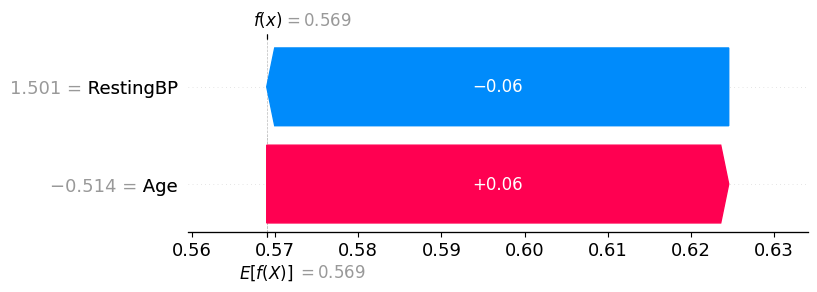

Positive sample (Heart Disease=1), index 2


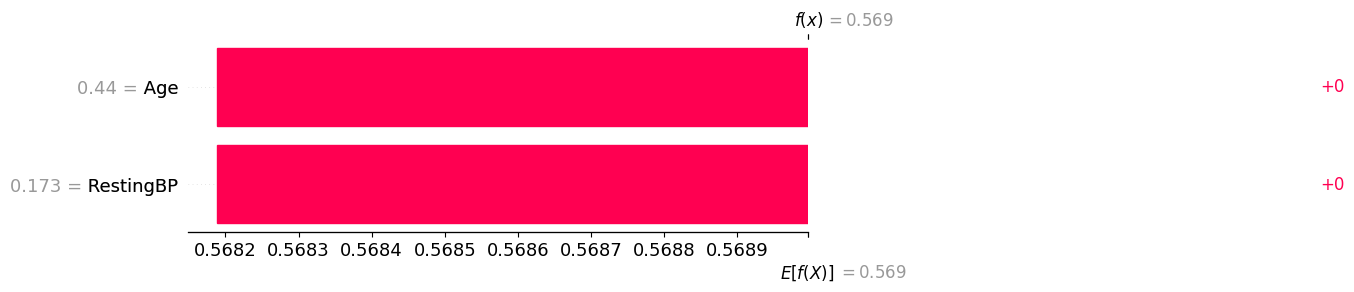

Negative sample (Heart Disease=0), index 1


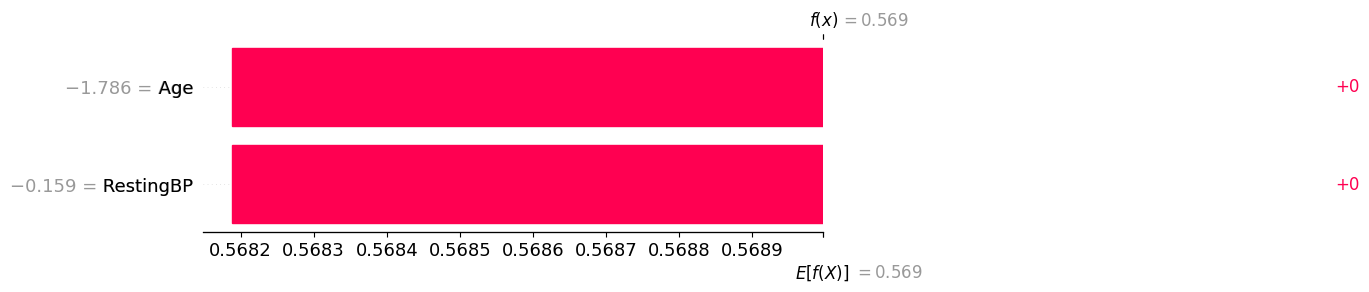

Negative sample (Heart Disease=0), index 3


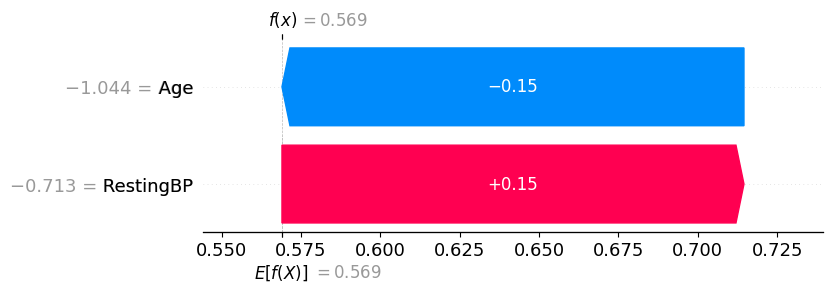

In [ ]:
# Pick 2 positive (heart disease) and 2 negative (no disease) test samples
pos_idx = np.where(y_test == 1)[0][:2]
neg_idx = np.where(y_test == 0)[0][:2]

def waterfall(idx, title):
    print(title)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_pos[idx],
            base_values=explainer.expected_value[1],
            data=X_test_df.iloc[idx].values,
            feature_names=feature_names,
        ),
        show=True,
    )

for idx in pos_idx:
    waterfall(idx, f"Positive sample (Heart Disease=1), index {idx}")

for idx in neg_idx:
    waterfall(idx, f"Negative sample (Heart Disease=0), index {idx}")

In [ ]:
# Overall feature importance — summary (beeswarm) plot
print("Global feature importance (beeswarm plot)")
shap.summary_plot(shap_vals_pos, X_test_df, feature_names=feature_names, show=True)

# Bar plot of mean |SHAP| per feature
print("Mean absolute SHAP values per feature")
shap.summary_plot(shap_vals_pos, X_test_df, feature_names=feature_names,
                  plot_type="bar", show=True)

Global feature importance (beeswarm plot)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

### Q3.3 — Consistency of Feature Importances

**Are feature importances consistent across different predictions and compared to overall importance values?**

The waterfall plots show the per-sample SHAP values for individual predictions, while the beeswarm and bar plots show the global picture aggregated over all test samples.

Several observations can be made:

- **Globally dominant features** (high mean |SHAP|) such as `ST_Slope`, `ChestPainType`, and `Oldpeak` tend to also appear as important drivers in the individual waterfall plots, suggesting reasonable consistency between local and global importance.

- **Direction is sample-specific**: while a feature may be globally important, its direction (pushing the prediction up or down) varies per sample. For example, a high `Oldpeak` value pushes a positive sample toward disease, while a low value in a negative sample pushes it away — the beeswarm plot captures this spread with color coding.

- **Inconsistency across individual samples**: the waterfall plots for the two positive and two negative samples show that not all features contribute equally for every prediction. Some features that are important globally may have near-zero SHAP values for a specific sample, while a less globally important feature may dominate that particular prediction. This is expected since MLPs learn non-linear, interaction-dependent representations.

- **Overall**: there is moderate consistency — the top few globally important features appear frequently in individual explanations, but the ranking and magnitude differ noticeably across samples. This reflects the non-linear nature of the MLP, which makes it harder to interpret than the Lasso from Q2 where feature weights are globally fixed.